/var/folders/kv/jhs4vb392hb9h62z_b83xjwm0000gn/T/ipykernel_85541/1769249162.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Start"] = pd.to_datetime(df["Start"])
/var/folders/kv/jhs4vb392hb9h62z_b83xjwm0000gn/T/ipykernel_85541/1769249162.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Season", "Weekday", "Bed_bin"])["Sleep_Hours"]


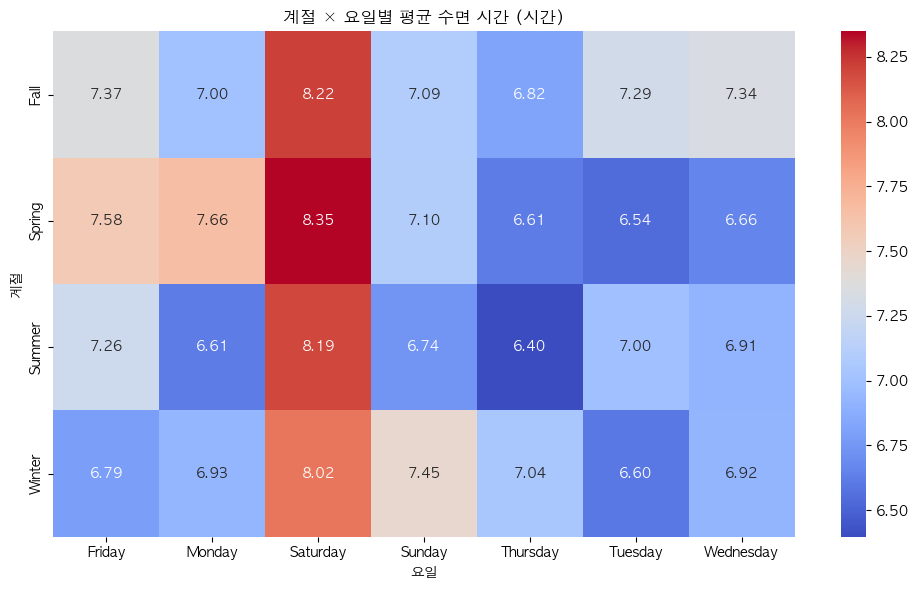


🔴 수면이 가장 짧았던 패턴 TOP 10
     Season   Weekday       Bed_bin  Sleep_Hours
475  Winter  Thursday  (20.0, 20.5]     2.883333
111    Fall   Tuesday  (28.0, 28.5]     3.350000
354  Summer  Thursday  (26.0, 26.5]     3.550000
203  Spring    Sunday  (26.5, 27.0]     3.666667
34     Fall    Monday  (27.5, 28.0]     3.750000
92     Fall  Thursday  (28.0, 28.5]     3.950000
439  Winter  Saturday  (21.0, 21.5]     4.116667
166  Spring    Monday  (27.0, 27.5]     4.166667
226  Spring  Thursday  (28.5, 29.0]     4.216667
219  Spring  Thursday  (25.0, 25.5]     4.233333

🟢 수면이 가장 길었던 패턴 TOP 10
     Season    Weekday       Bed_bin  Sleep_Hours
175  Spring   Saturday  (22.0, 22.5]    13.175000
268  Summer     Friday  (21.0, 21.5]    12.316667
3      Fall     Friday  (21.5, 22.0]    12.216667
57     Fall     Sunday  (20.0, 20.5]    12.100000
438  Winter   Saturday  (20.5, 21.0]    12.000000
77     Fall   Thursday  (20.5, 21.0]    11.800000
95     Fall    Tuesday  (20.0, 20.5]    11.750000
163  Spring  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. 한글 폰트 설정 (OS별)
# =========================
plt.rcParams["axes.unicode_minus"] = False
try:
    plt.rcParams["font.family"] = "AppleGothic"   # macOS
except:
    plt.rcParams["font.family"] = "Malgun Gothic" # Windows

# =========================
# 2. CSV 파일 로딩
# =========================
df = pd.read_csv("Export.csv")

# =========================
# 3. 날짜/시간 전처리
# =========================
df["Start"] = pd.to_datetime(df["Start"])
df["End"] = pd.to_datetime(df["End"])
df["Sleep_Hours"] = df["Duration"] / 60

# 취침 시각 (0~24 → 자정 이후는 +24 처리)
df["Bedtime"] = df["Start"].dt.hour + df["Start"].dt.minute / 60
df["Bedtime24"] = df["Bedtime"].apply(lambda x: x if x >= 12 else x + 24)

# 요일
df["Weekday"] = df["Start"].dt.day_name()

# 계절
df["Month"] = df["Start"].dt.month
def season(m):
    if m in [12,1,2]: return "Winter"
    if m in [3,4,5]: return "Spring"
    if m in [6,7,8]: return "Summer"
    return "Fall"

df["Season"] = df["Month"].apply(season)

# =========================
# 4. 취침 시각 구간화 (30분 단위)
# =========================
bins = np.arange(20, 30, 0.5)  # 20:00 ~ 05:30
df["Bed_bin"] = pd.cut(df["Bedtime24"], bins)

# =========================
# 5. 계절 × 요일 × 취침시간 평균 수면 계산
# =========================
interaction = (
    df.groupby(["Season", "Weekday", "Bed_bin"])["Sleep_Hours"]
      .mean()
      .reset_index()
)

# =========================
# 6. 히트맵용 피벗 테이블 생성
# =========================
pivot = df.pivot_table(
    index="Season",
    columns="Weekday",
    values="Sleep_Hours",
    aggfunc="mean"
)

# =========================
# 7. 히트맵 시각화
# =========================
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("계절 × 요일별 평균 수면 시간 (시간)")
plt.xlabel("요일")
plt.ylabel("계절")
plt.tight_layout()
plt.show()

# =========================
# 8. 최악 / 최적 패턴 출력
# =========================
print("\n🔴 수면이 가장 짧았던 패턴 TOP 10")
print(interaction.sort_values("Sleep_Hours").head(10))

print("\n🟢 수면이 가장 길었던 패턴 TOP 10")
print(interaction.sort_values("Sleep_Hours", ascending=False).head(10))
